# Geophysics: Ground Motion

# Geophysics: from sketch to notebook

**Question:** Is the ground moving in this area over time?

Reference notebook for The Pond. All observations and locations are **synthetic**, created for this activity; results are not evidence about a real site.

## Preamble: From sketch to notebook

In a previous [LiLyPad](https://linked.earth/ThePond/lilypads/workflow/sketching-workflows/index.html), you sketched a workflow to investigate ground movement over time.

Here, we use daily position measurements from several Global Navigation Satellite System (GNSS) stations. These stations are anchored to the ground, allowing repeated measurements of their positions to reveal movement.

We will standardize the positions, apply quality-control and uncertainty criteria, and retain stations with at least three years of observations. For each remaining station, we will estimate east–west and north–south movement rates, then combine them to calculate the speed and direction of horizontal ground movement.

In this notebook, we will translate that sketch into a computational workflow. As you work through each section, notice:

- What data does the step receive?
- What operation does it perform?
- What parameters or decisions control that operation?
- What does it produce, and which step uses that output?

An output does not need to be saved as a separate file. It can be a table or another object held in memory, provided we explain what it contains and how it is used.

Follow each input → analysis → output connection in your sketch. Markdown explains meaning, documents choices, and describes manual steps; code performs computational operations; displayed tables and figures let us inspect the results.

<div class="alert alert-block alert-info">
    <b>Note:</b> A notebook’s preamble introduces the scientific questions it addresses and explains how its analyses fit into the broader study. It is also a useful place to document data sources and software dependencies, including their versions.
</div>

## Exploratory Data Analysis

Let's first load our data and understand how it is organized.

Each row is one daily observation. `station` identifies the GNSS station, and `date` gives the observation date. `east` and `north` record its horizontal position components, with `unit` indicating meters (`m`) or millimeters (`mm`). Positive values point east and north, respectively.

The `frame` column identifies the reference frame used to report each position. Our synthetic dataset uses two fictional frames, A and B, which we will convert to a common frame before analysis.

`horizontal_uncertainty_mm` gives the reported horizontal measurement uncertainty in millimeters. `qc_complete` indicates whether quality control was completed and the measurement accepted (1) or remains incomplete (0).

Finally, `map_east_km` and `map_north_km` give fixed station locations on a local map, in kilometers. We will use these to position the velocity arrows in our final figure.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

raw = pd.read_csv("data/geophysics.csv")

print(f"Input: {len(raw)} daily observations")
display(raw.head())

Input: 6209 daily observations


,station,date,east,north,unit,frame,horizontal_uncertainty_mm,qc_complete,map_east_km,map_north_km
0,G1,2019-01-01,-0.000625,0.001372,m,A,12,0,10,6
1,G1,2019-01-02,99.281148,-48.949710,mm,B,2,1,10,6
2,G1,2019-01-03,-0.603323,-0.222897,mm,A,2,1,10,6
3,G1,2019-01-04,0.100937,-0.050366,m,B,2,1,10,6
4,G1,2019-01-05,-0.670823,0.050816,mm,A,2,1,10,6


## Data Pre-Processing

Our first step is to express all positions in millimeters and in reference frame A. We multiply positions reported in meters by 1,000; values already in millimeters remain unchanged.

In our synthetic dataset, frame B reports east positions 100 mm higher and north positions 50 mm lower than frame A. After converting the units, we subtract 100 mm from the east component and add 50 mm to the north component for observations in frame B.

We retain the original columns and store the standardized positions in `east_mm` and `north_mm`. We also convert the dates into a format that lets us calculate elapsed time.

<div class="alert alert-block alert-info">
    <b>Note:</b> These fictional reference frames differ only by constant offsets. This simplifies the conversion for the exercise. Transformations between real GNSS reference frames can be more complex and require an appropriate transformation model.
</div>

In [2]:
standardized = raw.copy()
standardized["date"] = pd.to_datetime(standardized["date"])

unit_factor = standardized["unit"].map({"m": 1000, "mm": 1})

east_offset_mm = standardized["frame"].map({"A": 0, "B": 100})
north_offset_mm = standardized["frame"].map({"A": 0, "B": -50})

standardized["east_mm"] = (
    standardized["east"] * unit_factor - east_offset_mm
)

standardized["north_mm"] = (
    standardized["north"] * unit_factor - north_offset_mm
)

assert standardized[["east_mm", "north_mm"]].notna().all().all()

display(
    standardized[
        ["station", "date", "unit", "frame", "east_mm", "north_mm"]
    ].head()
)

,station,date,unit,frame,east_mm,north_mm
0,G1,2019-01-01,m,A,-0.624949,1.371646
1,G1,2019-01-02,mm,B,-0.718852,1.050290
2,G1,2019-01-03,mm,A,-0.603323,-0.222897
3,G1,2019-01-04,m,B,0.936832,-0.365928
4,G1,2019-01-05,mm,A,-0.670823,0.050816


We now retain only observations for which quality control was completed and the measurement accepted, indicated by `qc_complete = 1`.

The resulting dataset contains accepted daily positions expressed in millimeters in reference frame A.

In [3]:
quality = standardized.loc[
    standardized["qc_complete"].eq(1)
].copy()

print(f"{len(standardized)} observations → {len(quality)} accepted observations")
display(quality.head())

6209 observations → 6063 accepted observations


,station,date,east,north,unit,frame,horizontal_uncertainty_mm,qc_complete,map_east_km,map_north_km,east_mm,north_mm
1,G1,2019-01-02,99.281148,-48.949710,mm,B,2,1,10,6,-0.718852,1.050290
2,G1,2019-01-03,-0.603323,-0.222897,mm,A,2,1,10,6,-0.603323,-0.222897
3,G1,2019-01-04,0.100937,-0.050366,m,B,2,1,10,6,0.936832,-0.365928
4,G1,2019-01-05,-0.670823,0.050816,mm,A,2,1,10,6,-0.670823,0.050816
5,G1,2019-01-06,100.087251,-49.597380,mm,B,2,1,10,6,0.087251,0.402620


We next remove observations with a reported horizontal uncertainty greater than 10 mm. Observations with an uncertainty exactly equal to 10 mm are retained.

The resulting dataset contains accepted daily positions that meet our uncertainty criterion. The uncertainty column is already expressed in millimeters, so no additional unit conversion is needed.

In [4]:
MAX_UNCERTAINTY_MM = 10

precise = quality.loc[
    quality["horizontal_uncertainty_mm"].le(MAX_UNCERTAINTY_MM)
].copy()

print(f"{len(quality)} observations → {len(precise)} with uncertainty ≤ 10 mm")
display(precise.head())

6063 observations → 5869 with uncertainty ≤ 10 mm


,station,date,east,north,unit,frame,horizontal_uncertainty_mm,qc_complete,map_east_km,map_north_km,east_mm,north_mm
1,G1,2019-01-02,99.281148,-48.949710,mm,B,2,1,10,6,-0.718852,1.050290
2,G1,2019-01-03,-0.603323,-0.222897,mm,A,2,1,10,6,-0.603323,-0.222897
3,G1,2019-01-04,0.100937,-0.050366,m,B,2,1,10,6,0.936832,-0.365928
4,G1,2019-01-05,-0.670823,0.050816,mm,A,2,1,10,6,-0.670823,0.050816
5,G1,2019-01-06,100.087251,-49.597380,mm,B,2,1,10,6,0.087251,0.402620


We now retain stations with at least three years of observations after quality-control and uncertainty filtering. For each station, we calculate the elapsed time between its first and last remaining observation, using 365.25 days per year.

The resulting dataset contains daily positions from stations whose retained records span at least three years.

<div class="alert alert-block alert-info">
    <b>Note:</b> We interpret record length as the time between the first and last retained observations. This does not guarantee continuous coverage: a station could have gaps within that period. We document this choice because requiring three years of daily measurements would be a different criterion.
</div>

In [5]:
MIN_YEARS = 3
DAYS_PER_YEAR = 365.25

record_lengths = (
    precise.groupby("station")["date"]
    .agg(first_date="min", last_date="max")
)

record_lengths["years"] = (
    (record_lengths["last_date"] - record_lengths["first_date"]).dt.days
    / DAYS_PER_YEAR
)

keep = record_lengths.index[
    record_lengths["years"].ge(MIN_YEARS)
]

eligible = precise.loc[
    precise["station"].isin(keep)
].copy()

display(record_lengths)

print(
    f"{precise['station'].nunique()} stations → "
    f"{eligible['station'].nunique()} with records spanning at least {MIN_YEARS} years"
)

,first_date,last_date,years
station,,,
G1,2019-01-02,2023-12-31,4.993840
G2,2019-01-02,2023-12-31,4.993840
G3,2019-01-02,2023-12-31,4.993840
G4,2019-01-02,2020-12-31,1.995893


4 stations → 3 with records spanning at least 3 years


## Analysis

For each retained station, we fit separate straight lines to its east and north positions over time. The slope of each line gives the movement rate in that direction, expressed in millimeters per year.

We measure time from each station’s first retained observation and give all retained observations equal weight in the fit. Positive slopes indicate movement eastward or northward; negative slopes indicate movement westward or southward.

The resulting table contains one row per station, with its east and north movement rates and its location for plotting.

<div class="alert alert-block alert-info">
    <b>Note:</b> A linear model describes movement at a constant average rate over the observation period. Here, we use ordinary least squares with an intercept and no uncertainty weighting. More detailed analyses may need to account for seasonal motion, sudden position changes, and correlated measurement errors.
</div>

In [6]:
records = []

for station, group in eligible.groupby("station"):
    time_years = (
        (group["date"] - group["date"].min()).dt.total_seconds()
        / (86400 * DAYS_PER_YEAR)
    )

    east_rate, east_intercept = np.polyfit(
        time_years, group["east_mm"], 1
    )

    north_rate, north_intercept = np.polyfit(
        time_years, group["north_mm"], 1
    )

    records.append({
        "station": station,
        "east_mm_yr": east_rate,
        "north_mm_yr": north_rate,
        "map_east_km": group["map_east_km"].iloc[0],
        "map_north_km": group["map_north_km"].iloc[0]
    })

trends = pd.DataFrame(records)

display(trends)

,station,east_mm_yr,north_mm_yr,map_east_km,map_north_km
0,G1,4.002121,1.989086,10,6
1,G2,1.992006,4.993067,20,12
2,G3,-2.992803,1.013062,30,18


We combine each station’s east and north movement rates to calculate its horizontal speed and direction. Speed is the square root of the sum of the squared component rates, expressed in millimeters per year.

We report direction clockwise from north: 0° indicates northward movement, 90° eastward, 180° southward, and 270° westward.

The resulting table retains the component rates and adds `speed_mm_yr` and `direction_deg`. These describe horizontal movement in our chosen reference frame.

In [7]:
velocities = trends.copy()

velocities["speed_mm_yr"] = np.hypot(
    velocities["east_mm_yr"],
    velocities["north_mm_yr"]
)

velocities["direction_deg"] = (
    np.degrees(
        np.arctan2(
            velocities["east_mm_yr"],
            velocities["north_mm_yr"]
        )
    ) % 360
)

# Direction is undefined when speed is zero.
velocities.loc[
    velocities["speed_mm_yr"].eq(0), "direction_deg"
] = np.nan

display(velocities)

,station,east_mm_yr,north_mm_yr,map_east_km,map_north_km,speed_mm_yr,direction_deg
0,G1,4.002121,1.989086,10,6,4.469165,63.572252
1,G2,1.992006,4.993067,20,12,5.375761,21.749743
2,G3,-2.992803,1.013062,30,18,3.159615,288.700935


## Visualization

Let's show each station’s horizontal movement as an arrow on a local map. The arrow points in the direction of movement, and its length represents speed. A reference arrow shows the length corresponding to 5 mm per year.

Station locations are expressed in kilometers, while velocities are expressed in millimeters per year. The arrows are enlarged for visibility; their endpoints do not represent future station locations.

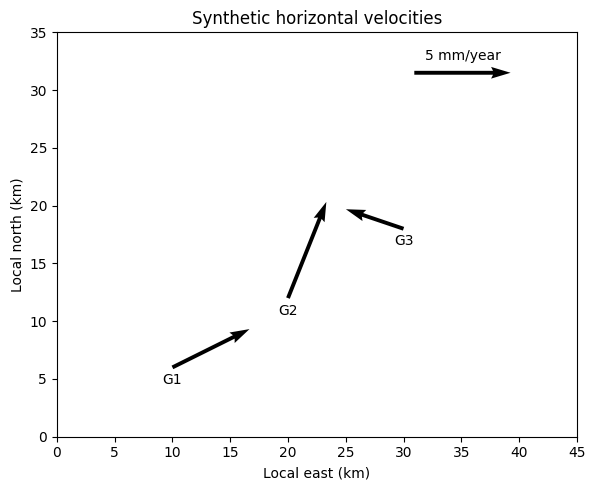

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

arrows = ax.quiver(
    velocities["map_east_km"],
    velocities["map_north_km"],
    velocities["east_mm_yr"],
    velocities["north_mm_yr"],
    angles="xy",
    scale_units="xy",
    scale=0.6
)

ax.quiverkey(
    arrows,
    X=0.78,
    Y=0.9,
    U=5,
    label="5 mm/year",
    coordinates="axes"
)

for row in velocities.itertuples():
    ax.annotate(
        row.station,
        (row.map_east_km, row.map_north_km),
        xytext=(0, -12),
        textcoords="offset points",
        ha="center"
    )

ax.set(
    xlim=(0, 45),
    ylim=(0, 35),
    aspect="equal",
    xlabel="Local east (km)",
    ylabel="Local north (km)",
    title="Synthetic horizontal velocities"
)

fig.tight_layout()

The retained stations show different horizontal movement speeds and directions in our chosen reference frame. Station G4 is excluded because its retained observations span less than three years.

These arrows summarize average movement over each station’s observation period. We have not estimated uncertainties in the fitted velocities, so the figure alone does not establish whether differences between stations are statistically significant.

<details>
<summary><strong>Show the reference workflow</strong></summary>

![Reference workflow for the geophysics scenario](./figures/geophysics-workflow-answer.png)

</details>